In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def print_multiple_accuracy(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("train_loss", "test_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        # train_acc = data["history"]["train_acc"]
        test_acc = data["history"]["test_acc"]


        print(label)
        # print("train_acc (finish):", train_acc[-1])
        print("test_acc (finish): ", test_acc[-1])
        print('\n')

In [3]:
# def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison", name=None):
#     """
#     run_dirs: пути к папкам
#     labels: подписи (["SignMuon", "Adam", "SGD", ...])
#     metric: что рисуем ("train_loss", "test_loss", ...)
#     """

#     plt.figure(figsize=(12, 8))

#     markers = ["o", "s", "^", "D", "v", "x", "*"] 

#     for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
#         run_dir = Path(run_dir)

#         with open(run_dir / "metrics.json", "r") as f:
#             data = json.load(f)

#         history = data["history"]
#         values = history[metric]

#         epochs = np.arange(1, len(values) + 1)

#         history = data["history"]
#         values = np.array(history[metric])

#         # Находим индексы, где значение меняется
#         # (или можно просто взять каждый 100-й элемент, если вы точно знаете шаг)
#         change_indices = [0]  # начинаем с первого элемента
#         for idx in range(1, len(values)):
#             if values[idx] != values[idx - 1]:  # значение изменилось
#                 change_indices.append(idx)
        
#         # Берём только изменённые значения
#         changed_values = values[change_indices]
#         changed_epochs = np.array(change_indices) + 1  # +1 если epochs с 1, иначе оставить как есть
        
#         plt.plot(
#             changed_epochs, 
#             changed_values, 
#         # plt.plot(
#         #     epochs, 
#         #     values, 
#             label=label,
#             linewidth=2.5,
#             # marker=markers[i % len(markers)],
#             # markersize=7, 
#             # markevery=len(changed_values)//4,
#         )

#     metric_names = {
#         "train_loss": "Train Loss",
#         "test_loss": "Test Loss",
#         "train_acc": "Train Accuracy",
#         "test_acc": "Test Accuracy",
#     }
#     ylabel = metric_names.get(metric, metric)
#     plt.ylabel(ylabel, fontsize=20)
#     plt.xlabel("Rounds", fontsize=20)
#     plt.xticks(fontsize=18)
#     plt.yticks(fontsize=18)
#     #plt.title(title)
#     plt.grid(True)
#     plt.legend(fontsize=18)
#     plt.tight_layout()
    
#     # plt.savefig(f"{name}.pdf", bbox_inches="tight", dpi=300)
#     if name is not None: 
#         plt.savefig(f"{name}.png", bbox_inches="tight", dpi=300)
    
#     plt.show()

In [4]:
# ============================================================
# Publication-ready plotting style (NeurIPS / ICML / AAAI)
# Run this cell once; all subsequent figures inherit the style.
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 1.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.9,
    "lines.linewidth": 3.5,
    "lines.markersize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.75",
    "legend.fancybox": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# tab10 first five + medium pink as the 6th (explicit hex codes).
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
          "#915cc2", "#37200E", "#10C5D5", "#4A3322", "#bcbd22", "#17becf"]
_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

_METRIC_NAMES = {
    "train_loss": "Train Loss",
    "test_loss": "Test Loss",
    "train_acc": "Train Accuracy",
    "test_acc": "Test Accuracy",
}


def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison",
                            xlabel="Rounds", ylabel=None, figsize=(10, 6.5),
                            markevery=None, save_path=None):
    """Plot one metric across several federated runs."""
    fig, ax = plt.subplots(figsize=figsize)

    for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
        run_dir = Path(run_dir)
        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        history = data["history"]
        values = np.array(history[metric])

        # Находим индексы, где значение меняется
        # (или можно просто взять каждый 100-й элемент, если вы точно знаете шаг)
        change_indices = [0]  # начинаем с первого элемента
        for idx in range(1, len(values)):
            if values[idx] != values[idx - 1]:  # значение изменилось
                change_indices.append(idx)
        
        # Берём только изменённые значения
        changed_values = values[change_indices]
        changed_epochs = np.array(change_indices) + 1  # +1 если epochs с 1, иначе оставить как есть

        me = markevery if markevery is not None else max(1, len(changed_values) // 6)
        color = COLORS[i % len(COLORS)]
        marker = _MARKERS[i % len(_MARKERS)]

        ax.plot(
            changed_epochs, 
            changed_values, 
            label=label,
            color=color,
            linewidth=3.5,
            alpha=0.85,
            # marker=marker,
            # markersize=11,
            # markerfacecolor=color,
            # markeredgecolor="white",
            # markeredgewidth=1.5,
            # markevery=me,
            solid_capstyle="round",
            zorder=3,
        )

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel if ylabel else _METRIC_NAMES.get(metric, metric), fontsize=20)
    ax.tick_params(axis="both", labelsize=16, length=6, width=1.3)
    ax.grid(True, linestyle="--", linewidth=0.9, alpha=0.25, zorder=0)
    ax.legend(loc="best", fontsize=16, frameon=True, framealpha=0.95, edgecolor="0.75")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

#  CIFAR10

### Обучение клиентов $\in [1, 3, 5, 7, 9]$ с SignMuon

In [5]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c1_s1",
        "signmuon_cl_homo_cnn2_r2000_c3_s1",
        "signmuon_cl_homo_cnn2_r2000_c5_s1",
        "signmuon_cl_homo_cnn2_r2000_c7_s1",
        "signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    title="CIFAR10",
)

CIFAR10
signmuon_cl_homo_cnn2_r2000_c1_s1
test_acc (finish):  76.13


signmuon_cl_homo_cnn2_r2000_c3_s1
test_acc (finish):  81.24


signmuon_cl_homo_cnn2_r2000_c5_s1
test_acc (finish):  82.87


signmuon_cl_homo_cnn2_r2000_c7_s1
test_acc (finish):  83.54


signmuon_cl_homo_cnn2_r2000_c9_s1
test_acc (finish):  84.03




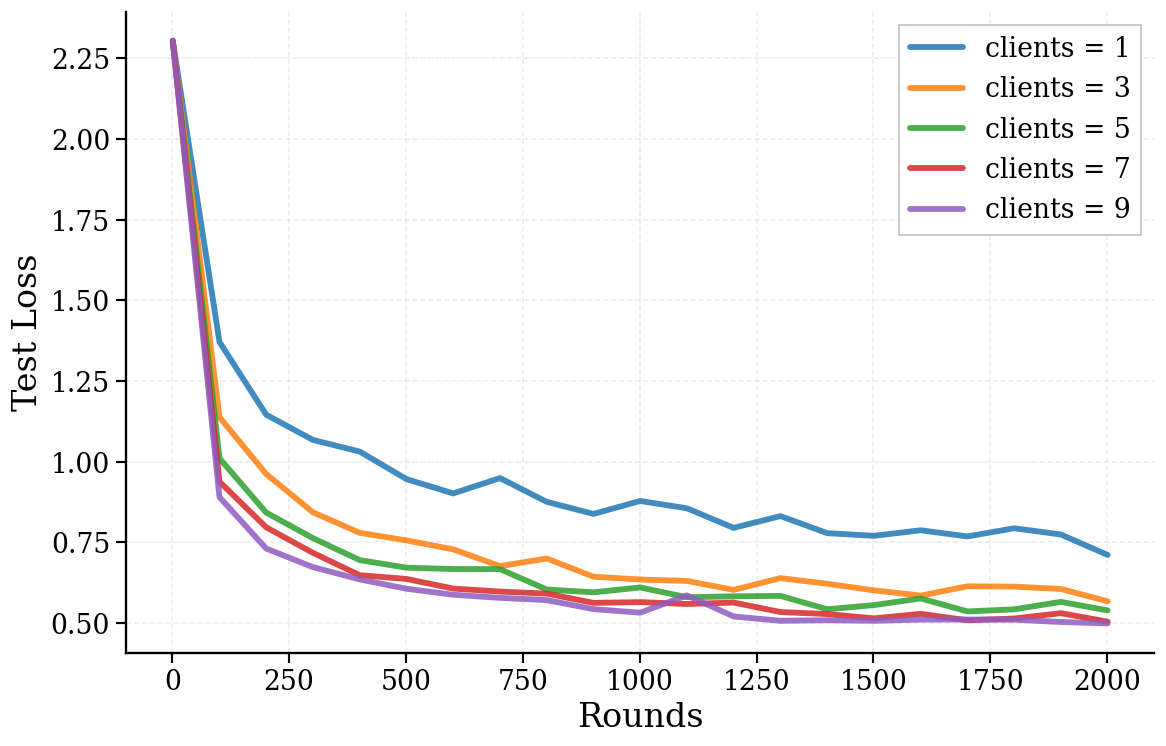

In [6]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "clients = 1",
        "clients = 3" ,
        "clients = 5",
        "clients = 7",
        "clients = 9"
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
    save_path="im_fed/signmuon_loss"
)

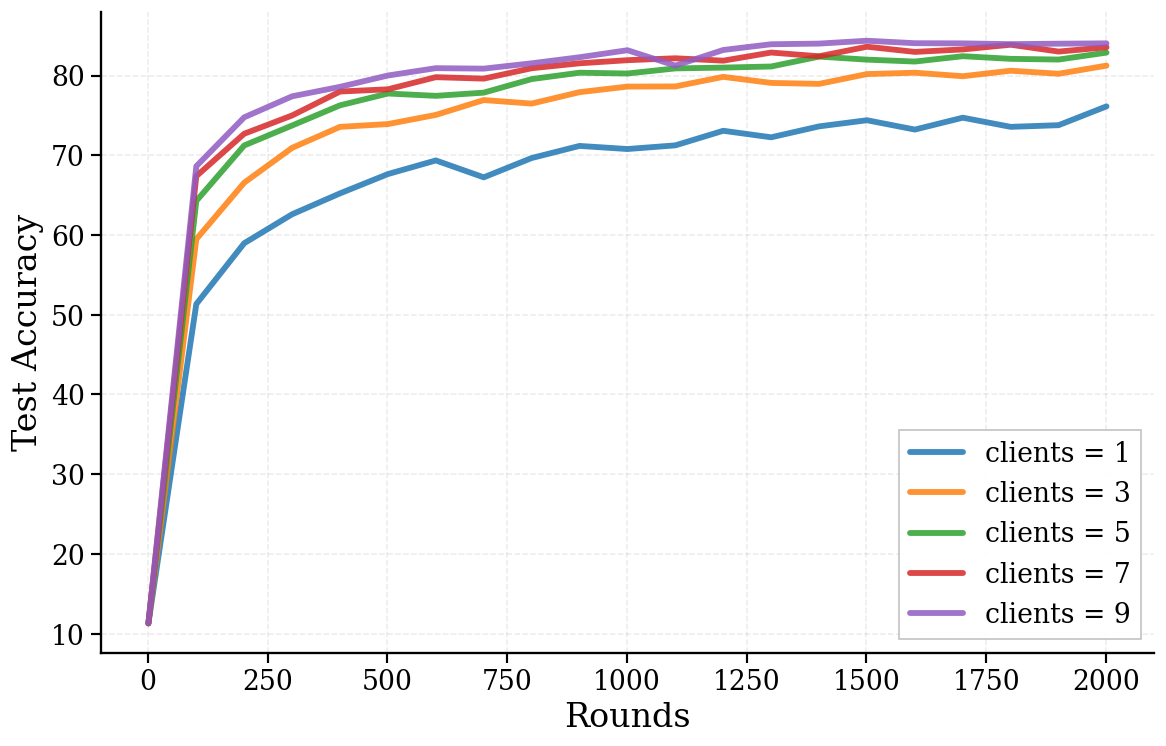

In [7]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "clients = 1",
        "clients = 3" ,
        "clients = 5",
        "clients = 7",
        "clients = 9"
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
    save_path="im_fed/signmuon_acc"
)

### Обучение 3 клиентов c шагом 1 с разными алгоритмами

In [8]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
        "saves_federated/fed_cifar10_signmuon_ef_ud_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-USignMuon",
        "EF-UDSignMuon",
    ],
    title="CIFAR10",
)

CIFAR10
SignMuon
test_acc (finish):  81.24


Muon
test_acc (finish):  81.27


SignSGD
test_acc (finish):  65.96


SGD
test_acc (finish):  76.77000000000001


Adam
test_acc (finish):  70.83


EF-USignMuon
test_acc (finish):  80.69


EF-UDSignMuon
test_acc (finish):  80.55




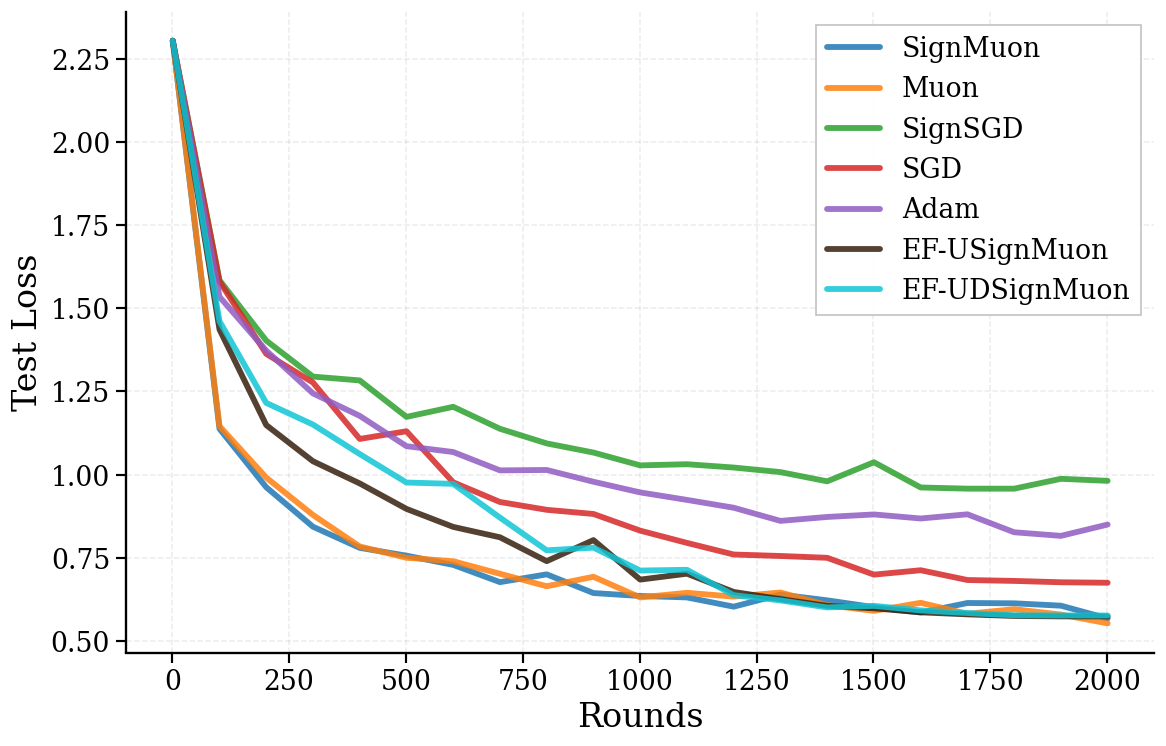

In [9]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
        "saves_federated/fed_cifar10_signmuon_ef_ud_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-USignMuon",
        "EF-UDSignMuon",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
    save_path="im_fed/3_1_loss"
)

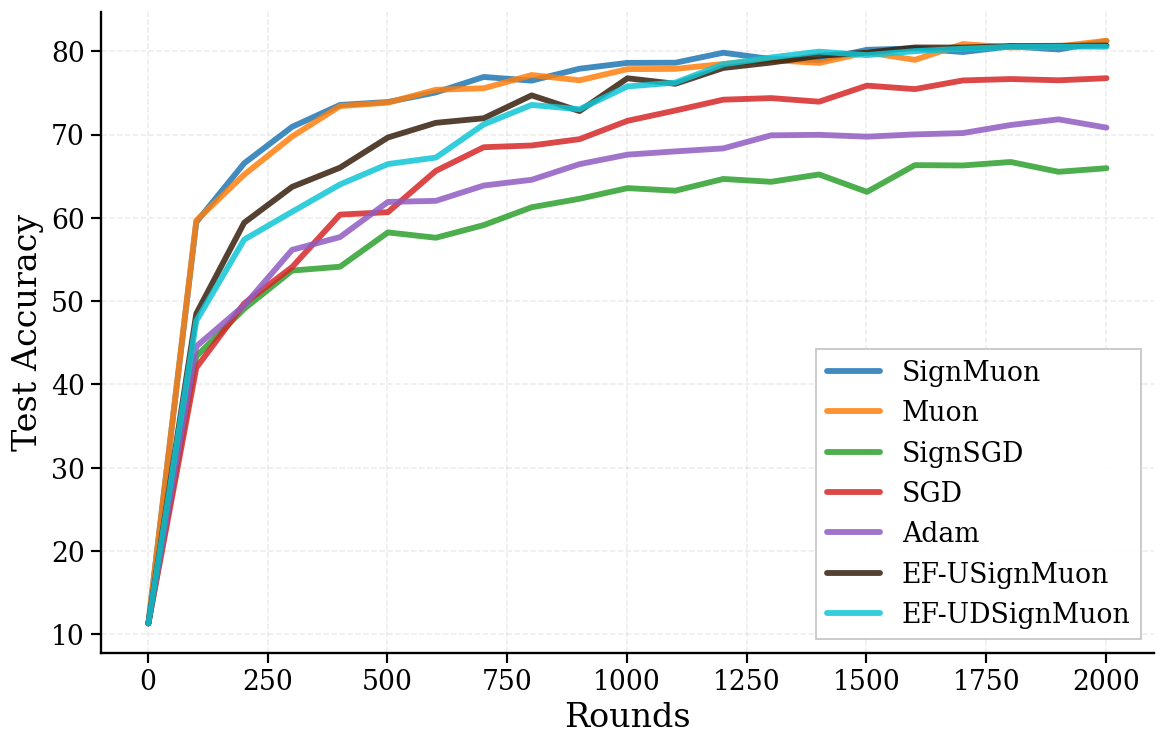

In [10]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
        "saves_federated/fed_cifar10_signmuon_ef_ud_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-USignMuon",
        "EF-UDSignMuon",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
    save_path="im_fed/3_1_acc"
)

### Обучение 10 клиентов шагом 3 с разными алгоритмами

In [11]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
        "saves_federated/fed_cifar10_signmuon_ef_ud_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-USignMuon",
        "EF-UDSignMuon",
    ],
    title="CIFAR10",
)

CIFAR10
SignMuon
test_acc (finish):  84.57000000000001


Muon
test_acc (finish):  85.22


SignSGD
test_acc (finish):  78.97999999999999


SGD
test_acc (finish):  81.38


Adam
test_acc (finish):  78.36


EF-USignMuon
test_acc (finish):  84.59


EF-UDSignMuon
test_acc (finish):  84.87




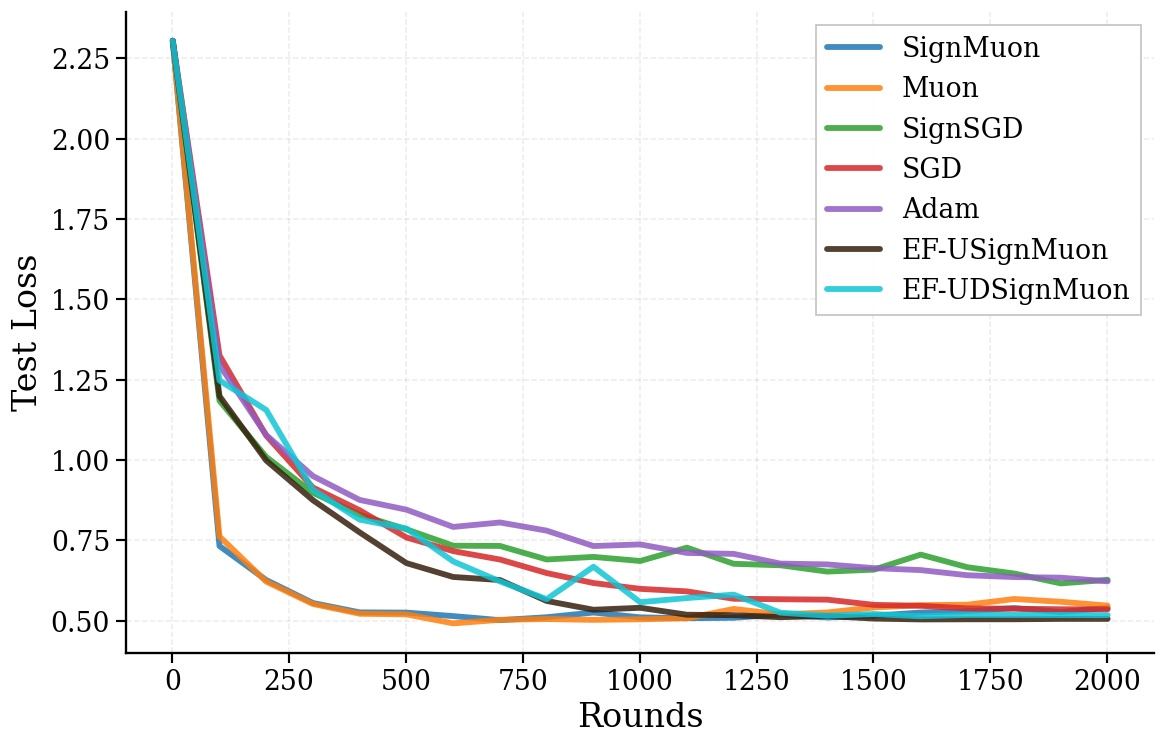

In [12]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
        "saves_federated/fed_cifar10_signmuon_ef_ud_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-USignMuon",
        "EF-UDSignMuon",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
    save_path ="im_fed/10_3_loss",
)

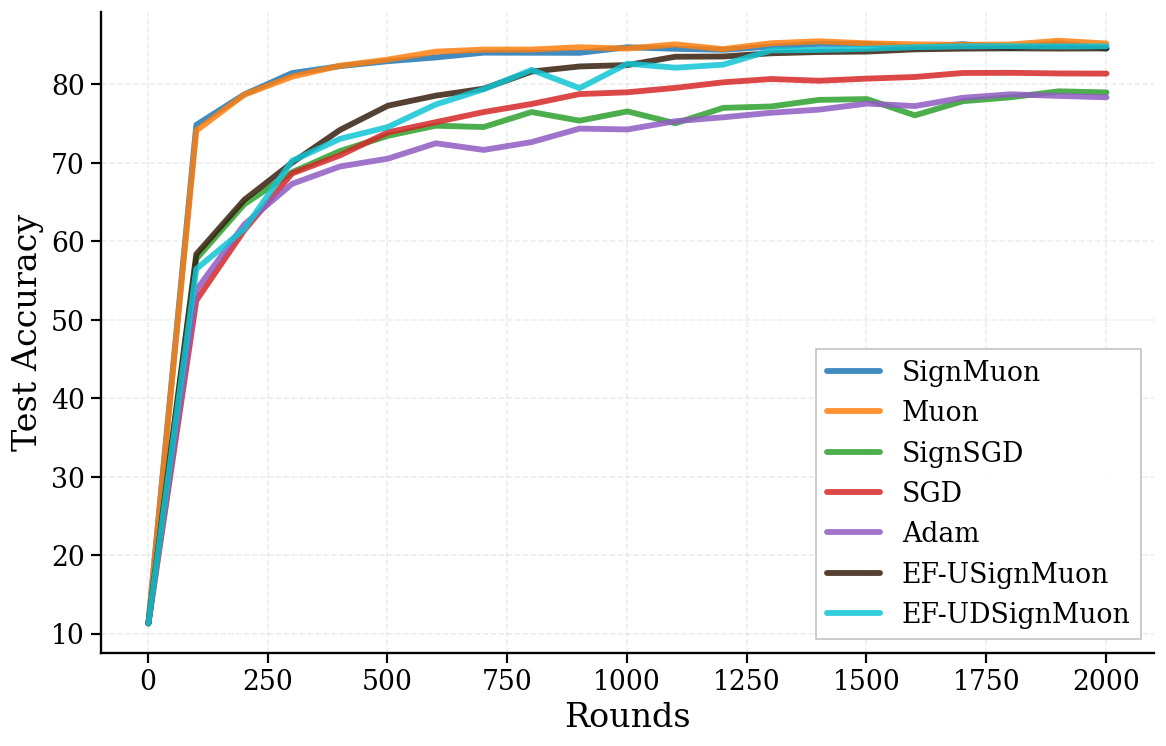

In [13]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
        "saves_federated/fed_cifar10_signmuon_ef_ud_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-USignMuon",
        "EF-UDSignMuon",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
    save_path ="im_fed/10_3_acc",
)

Сравнение EF и EF_21


In [14]:
# print_multiple_accuracy(
#     run_dirs=[
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
#     ],
#     labels=[
#         "EF-USignMuon",
#         "EF-USignMuon_21",
#     ],
#     title="CIFAR10",
# )

In [15]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
#     ],
#     labels=[
#         "EF-USignMuon",
#         "EF-USignMuon_21",
#     ],
#     metric="test_loss",
#     title="CIFAR10 test loss",
# )

In [16]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
#     ],
#     labels=[
#         "EF-USignMuon",
#         "EF-USignMuon_21",
#     ],
#     metric="test_acc",
#     title="CIFAR10 test accuracy",
# )

In [17]:
# print_multiple_accuracy(
#     run_dirs=[
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
#     ],
#     labels=[
#         "EF-USignMuon",
#         "EF-USignMuon_21",
#     ],
#     title="CIFAR10",
# )

In [18]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
#     ],
#     labels=[
#         "EF-USignMuon",
#         "EF-USignMuon_21",
#     ],
#     metric="test_loss",
#     title="CIFAR10 test loss",
# )

In [19]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
#         "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
#     ],
#     labels=[
#         "EF-USignMuon",
#         "SignMuon_EF_21",
#     ],
#     metric="test_acc",
#     title="CIFAR10 test loss",
# )